In [16]:
import operator
import re
from langgraph.graph import StateGraph,START, END
from typing import TypedDict,Annotated

StateGraph

In [17]:
class ReviewState(TypedDict):
    raw_review:str
    sentiment:str
    category_tag:list[str]
    audit_log:Annotated[list[str],operator.add]

In [18]:
def cleaner_function(text:str,terget:set[str]):
     cleaned_review_word=re.sub(r'[^\w\s]','',text).lower().split()
     master_word=set(cleaned_review_word)
     is_present=terget.issubset(master_word)
     return is_present

In [19]:
def clean_score_node(state:ReviewState):
    target_word={"great", "love", "excellent"}
    is_present=cleaner_function(state["raw_review"],target_word)
    if is_present:
        sentiment="POSITIVE"
    else:
        sentiment="NEGATIVE"
    return {
        "sentiment":sentiment,
        "audit_log":["step1:raw data cleaned and " + sentiment + " sentiment added"]
    }


In [20]:
def tag_node(state:ReviewState):
    target_word={"refund", "card","price"}
    tech_word={"app", "bug","login"}
    bill_present=cleaner_function(state["raw_review"],target_word)
    tech_present=cleaner_function(state["raw_review"],tech_word)
    if bill_present:
        category_tag="Billing"
    elif tech_word:
        category_tag="Technical"
    return{
        "category_tag":category_tag,
        "audit_log":["step2:category tag " + category_tag +" added"]
    }


In [21]:
def summary_node(state:ReviewState):
    summary=f"Review evaluated as {state["sentiment"]} with tag {state["category_tag"]}"
    return{
        "audit_log":[
            f"step3:{summary}",
            "Step 3: Final Triage Complete."
        ]
    }

In [22]:
builder=StateGraph(ReviewState)

In [23]:
#add node
builder.add_node("Sentiment",clean_score_node)
builder.add_node("Category",tag_node)
builder.add_node("Summary",summary_node)



In [24]:
# Connect the nodes through edge
builder.add_edge(START,"Sentiment")
builder.add_edge("Sentiment","Category")
builder.add_edge("Category","Summary")
builder.add_edge("Summary",END)


In [25]:
# Compile the graph into an executable application
app=builder.compile()

The graph will be


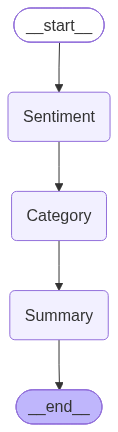

In [26]:
from IPython.display import display,Image
print("The graph will be")
display(Image(app.get_graph().draw_mermaid_png()))

In [27]:
initial_input = {
     "raw_review":"The app keeps crashing after the update, I want a refund!"
}

output = app.invoke(initial_input)

In [28]:
print("Analysis: ", output["sentiment"])
print("Audit log:")
for log in output["audit_log"]:
    print(f"- {log}")

Analysis:  NEGATIVE
Audit log:
- step1:raw data cleaned and NEGATIVE sentiment added
- step2:category tag Technical added
- step3:Review evaluated as NEGATIVE with tag Technical
- Step 3: Final Triage Complete.
